In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv(r"C:\Users\Nitesh\Downloads\transactions_train_data.csv")
test = pd.read_csv(r"C:\Users\Nitesh\Downloads\transactions_test.csv")

train.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,359131,2023-01-01 00:02:00.328105993,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,...,desktop,0,0.142532,1,3,1,33.458018,2205.262235,0,0.099920
1,351207,2023-01-01 00:02:26.339769237,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,...,mobile,0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
2,10209,2023-01-01 00:06:54.145825305,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,...,desktop,0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647
3,62660,2023-01-01 00:06:57.723185583,4041,2525,1914,1,1,2906.711704,0.202223,610.407487,...,mobile,0,0.171764,1,2,0,18.840187,513.517097,0,0.354154
4,384254,2023-01-01 00:08:05.487541188,3979,1555,360,2,3,5082.651983,0.171230,986.397163,...,mobile,0,0.248766,1,1,0,15.344375,816.975430,0,0.149084


In [3]:
# checking the data set 

train.shape
train.columns
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300113 entries, 0 to 300112
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   300113 non-null  int64  
 1   transaction_time                 300113 non-null  object 
 2   customer_id                      300113 non-null  int64  
 3   merchant_id                      300113 non-null  int64  
 4   account_age_days                 300113 non-null  int64  
 5   credit_score_band                300113 non-null  int64  
 6   kyc_level                        300113 non-null  int64  
 7   avg_monthly_spend                300113 non-null  float64
 8   merchant_risk_score              300113 non-null  float64
 9   transaction_amount               300113 non-null  float64
 10  payment_channel                  300113 non-null  object 
 11  device_type                      300113 non-null  object 
 12  is

In [4]:
train.shape

(300113, 21)

In [5]:
train.columns


Index(['transaction_id', 'transaction_time', 'customer_id', 'merchant_id',
       'account_age_days', 'credit_score_band', 'kyc_level',
       'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount',
       'payment_channel', 'device_type', 'is_international', 'ip_risk_score',
       'txn_count_1h', 'txn_count_24h', 'failed_txn_count_24h',
       'geo_distance_from_last_txn', 'amount_deviation_from_user_mean',
       'is_fraud', 'post_auth_risk_score'],
      dtype='object')

In [6]:
#Data Cleaning -> Convert time column:

train['transaction_time'] = pd.to_datetime(train['transaction_time'])

In [7]:
# checcking -> is their any missing value ot not 

train.isnull().sum()

transaction_id                     0
transaction_time                   0
customer_id                        0
merchant_id                        0
account_age_days                   0
credit_score_band                  0
kyc_level                          0
avg_monthly_spend                  0
merchant_risk_score                0
transaction_amount                 0
payment_channel                    0
device_type                        0
is_international                   0
ip_risk_score                      0
txn_count_1h                       0
txn_count_24h                      0
failed_txn_count_24h               0
geo_distance_from_last_txn         0
amount_deviation_from_user_mean    0
is_fraud                           0
post_auth_risk_score               0
dtype: int64

In [8]:
# now removing any missing row if it is present

train = train.dropna()

In [9]:
# total transaction 

len(train)

300113

In [10]:
# now will focus on fraud vs normal transaction 
train['is_fraud'].value_counts()

is_fraud
0    295242
1      4871
Name: count, dtype: int64

In [11]:
## this code genrated by me
train.is_fraud.sum()

np.int64(4871)

In [12]:
train.is_fraud.value_counts()

is_fraud
0    295242
1      4871
Name: count, dtype: int64

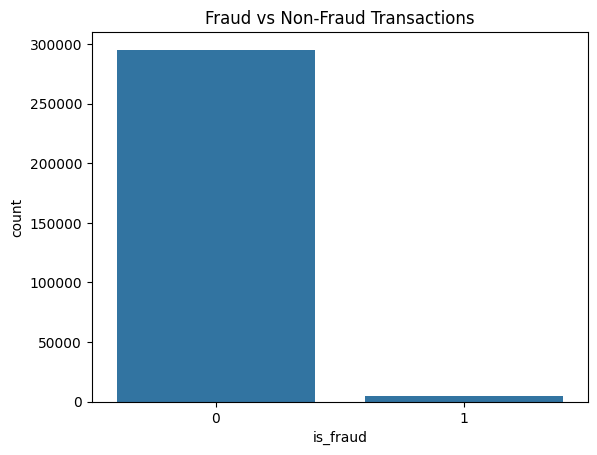

In [13]:
# visualization 

sns.countplot(x='is_fraud', data=train)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

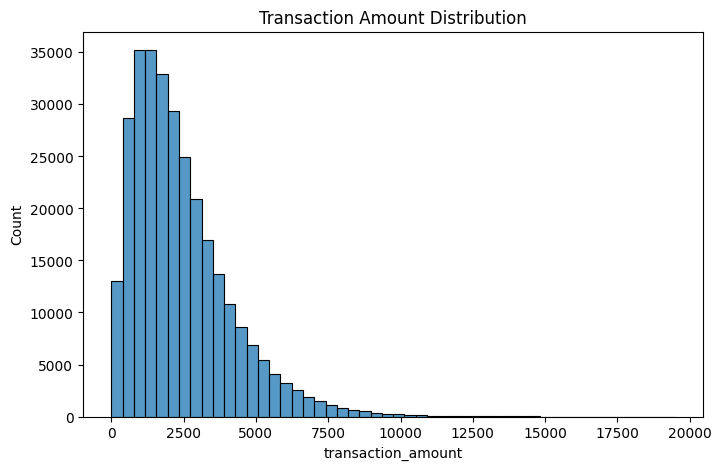

In [14]:
# this is transaction amount analysis

plt.figure(figsize=(8,5))
sns.histplot(train['transaction_amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

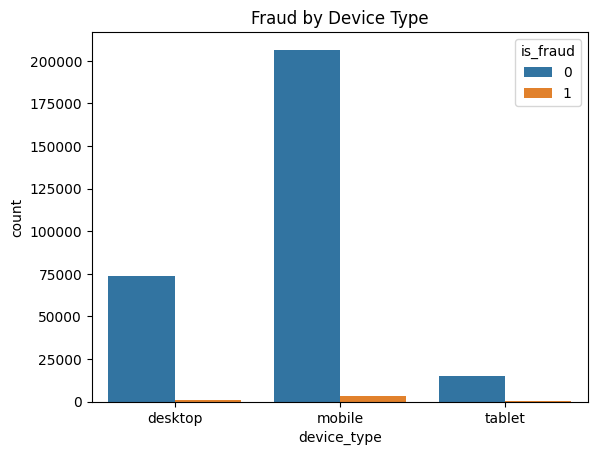

In [15]:
# fraud by device type

sns.countplot(x='device_type', hue='is_fraud', data=train)
plt.title("Fraud by Device Type")
plt.show()

In [16]:
# time base fraud analysis

train['hour'] = train['transaction_time'].dt.hour
train['day'] = train['transaction_time'].dt.day

In [17]:
cols_to_drop = [
    'is_fraud',
    'transaction_time',
    'post_auth_risk_score',
    'merchant_risk_score',
    'ip_risk_score',
    'transaction_id',
    'customer_id',
    'merchant_id',
    'risk_level_Medium Risk',
    'risk_level_High Risk'
]

X = train.drop(columns=[col for col in cols_to_drop if col in train.columns])

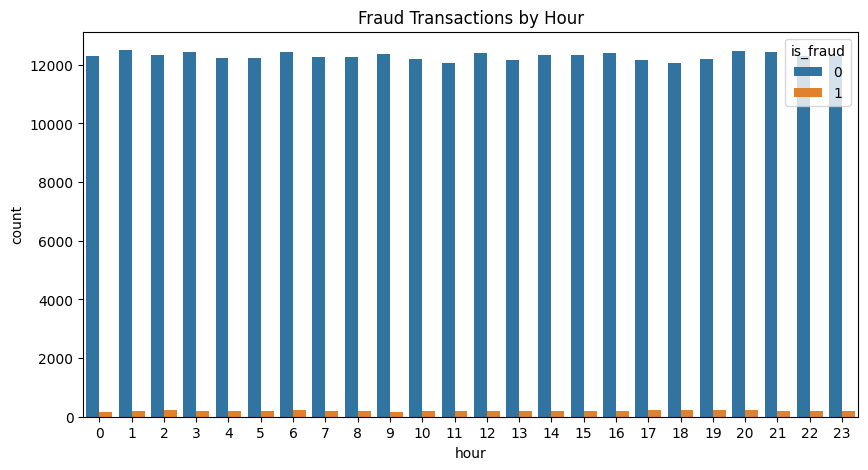

In [18]:
# fraud by hour

plt.figure(figsize=(10,5))
sns.countplot(x='hour', hue='is_fraud', data=train)
plt.title("Fraud Transactions by Hour")
plt.show()

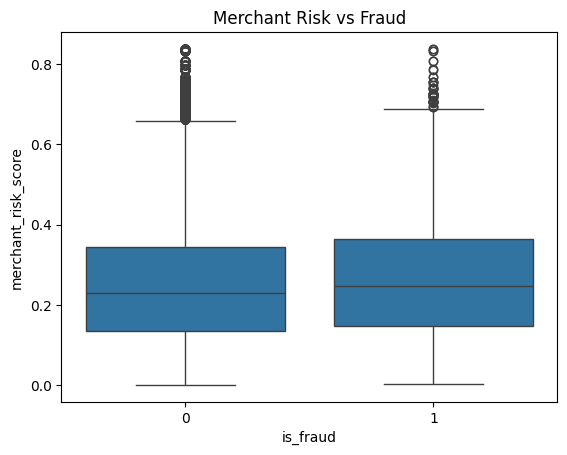

In [19]:
# merchant risk analysis

sns.boxplot(x='is_fraud', y='merchant_risk_score', data=train)
plt.title("Merchant Risk vs Fraud")
plt.show()

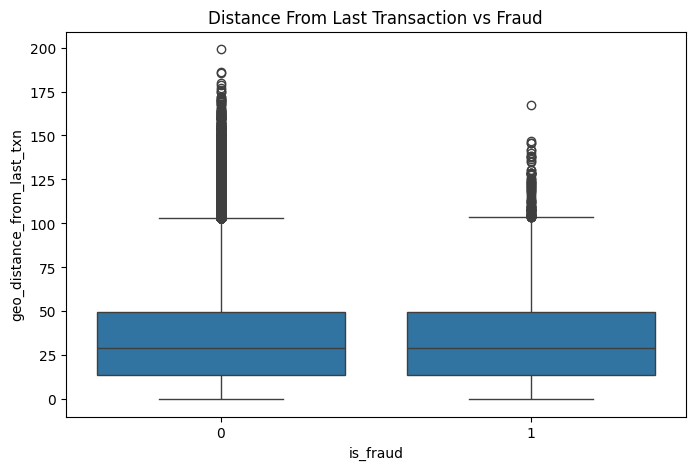

In [20]:

# Geo distance analysis
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='geo_distance_from_last_txn', data=train)
plt.title("Distance From Last Transaction vs Fraud")
plt.show()

In [21]:
print(train.columns)

Index(['transaction_id', 'transaction_time', 'customer_id', 'merchant_id',
       'account_age_days', 'credit_score_band', 'kyc_level',
       'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount',
       'payment_channel', 'device_type', 'is_international', 'ip_risk_score',
       'txn_count_1h', 'txn_count_24h', 'failed_txn_count_24h',
       'geo_distance_from_last_txn', 'amount_deviation_from_user_mean',
       'is_fraud', 'post_auth_risk_score', 'hour', 'day'],
      dtype='object')


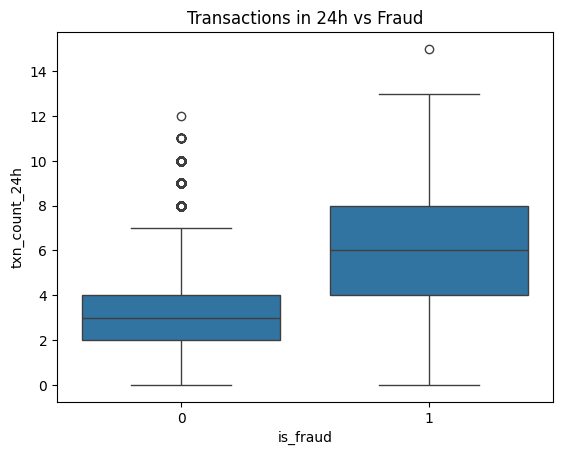

In [22]:
sns.boxplot(x='is_fraud', y='txn_count_24h', data=train)
plt.title("Transactions in 24h vs Fraud")
plt.show()

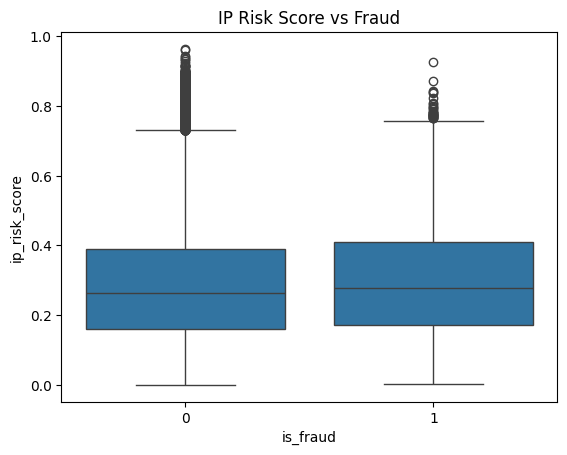

In [23]:
sns.boxplot(x='is_fraud', y='ip_risk_score', data=train)
plt.title("IP Risk Score vs Fraud")
plt.show()

In [24]:
train['risk_level'] = pd.cut(
    train['merchant_risk_score'],
    bins=[0,3,7,10],
    labels=['Low Risk','Medium Risk','High Risk']
)

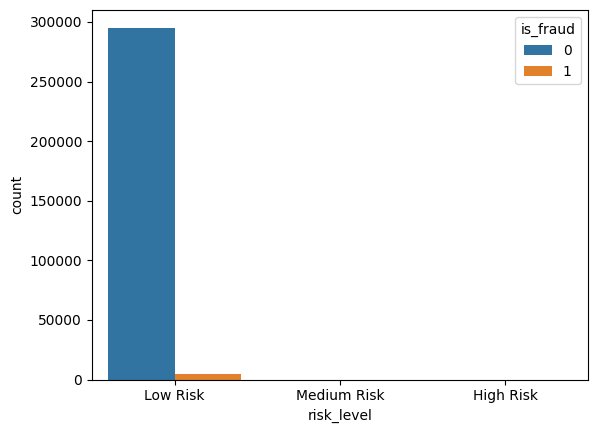

In [25]:
sns.countplot(x='risk_level', hue='is_fraud', data=train)
plt.show()

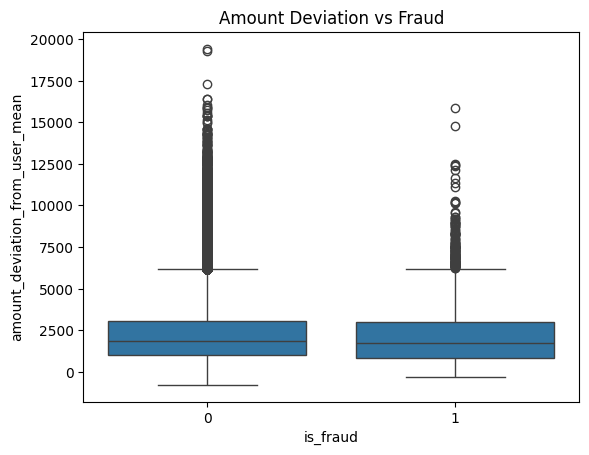

In [26]:
sns.boxplot(x='is_fraud', y='amount_deviation_from_user_mean', data=train)
plt.title("Amount Deviation vs Fraud")
plt.show()

In [27]:
#Fraud Rate Analysis.

fraud_rate = train.groupby('payment_channel')['is_fraud'].mean().sort_values(ascending=False)
fraud_rate

payment_channel
card             0.016439
upi              0.016257
bank_transfer    0.015899
wallet           0.015716
Name: is_fraud, dtype: float64

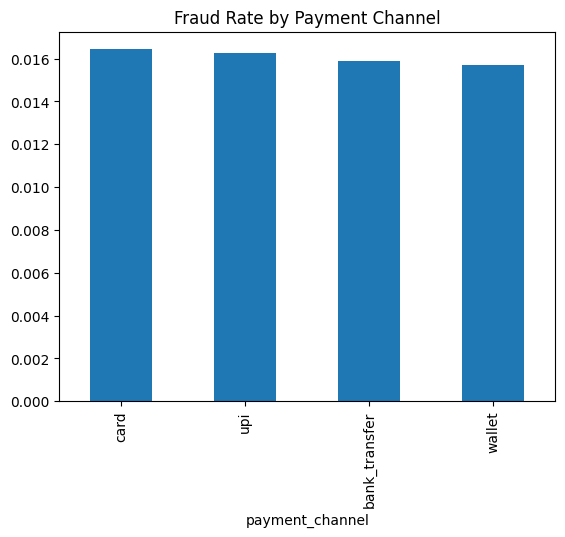

In [28]:
fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Payment Channel")
plt.show()

In [29]:
# Key Insights from Transaction Analysis

# Fraud transactions are higher for merchants with high risk scores.

# Transactions with large deviation from user spending patterns are more likely to be fraudulent.

# Increased transaction frequency in 24 hours is linked with suspicious activity.

# Certain payment channels show a higher fraud rate.

#Transactions far from the last transaction location indicate higher fraud probability.

In [30]:
# This analysis helps identify patterns associated with fraudulent transactions in digital payment systems. The insights can assist payment platforms in monitoring high-risk activities and improving fraud prevention strategies.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report



In [32]:
# features & target
X = train.drop(['is_fraud','transaction_time'], axis=1)
y = train['is_fraud']



In [33]:
# encoding
X = pd.get_dummies(X, drop_first=True)



In [34]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [35]:
# model
model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
# prediction
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59038
           1       1.00      1.00      1.00       985

    accuracy                           1.00     60023
   macro avg       1.00      1.00      1.00     60023
weighted avg       1.00      1.00      1.00     60023

